Load libraries and data

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import fasttext
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns
import re
from scipy import stats
import geopandas as gpd
import geobr

In [164]:
def average_vector(words):
    vectors = [ft.get_word_vector(w) for w in words]
    return np.mean(vectors, axis=0)

def document_vector(text):
    words = text.split()
    vectors = [ft.get_word_vector(w) for w in words]
    return np.mean(vectors, axis=0)

In [165]:
ft = fasttext.load_model('..\session_5_embs\cc.pt.300.bin')
olist_data = pd.read_parquet("data/olist_liwc_scores.parquet")
utlc_movies = pd.read_parquet("data/utlc_movies_liwc_scores.parquet")
utlc_movies = (
    utlc_movies
    .groupby("polarity", group_keys=False)
    .apply(lambda x: x.sample(n=25000, random_state=42))
    .reset_index(drop=True)
)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\fabio\AppData\Local\Temp\ipykernel_9472\1573788512.py:1: SyntaxWarning: invalid escape sequence '\s'
  ft = fasttext.load_model('..\session_5_embs\cc.pt.300.bin')
C:\Users\fabio\AppData\Local\Temp\ipykernel_9472\1573788512.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=25000, random_state=42))


In [209]:
review_data = utlc_movies  # select review data

review_data = review_data.dropna(subset=["polarity"])
mask = (
    review_data["review_text_processed"].isna() |
    review_data["review_text_processed"].str.strip().eq("")
)
review_data = review_data[~mask]

review_data = review_data.rename(columns={"polarity": "review"})
review_data["review"] = review_data["review"].map({1: "positive", 0: "negative"})

len(review_data)


50000

In [210]:
review_data["review"].value_counts()

review
negative    25000
positive    25000
Name: count, dtype: int64

Let's start with LIWC

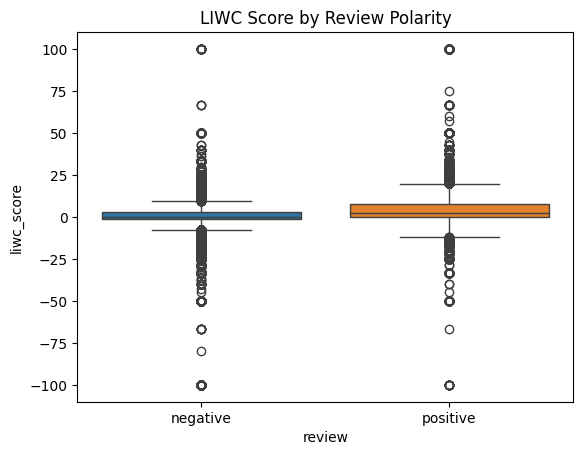

In [211]:
sns.boxplot(data=review_data, x="review", y="liwc_score", hue="review")
plt.title("LIWC Score by Review Polarity")
plt.show()

In [213]:
review_data.sort_values("liwc_score", ascending=False)[
    ["review_text_processed", "liwc_score"]
].tail(10)

,review_text_processed,liwc_score
14717,decepcionante,-100.0
1567,fraco,-100.0
20558,porcaria,-100.0
14553,decepcionante,-100.0
7212,chato,-100.0
14467,fraco,-100.0
20524,decepcionante,-100.0
20510,macabro,-100.0
38655,sinistroo,-100.0
18341,bosta,-100.0


In [214]:
review_data["review_length"] = (
    review_data["review_text_processed"]
    .str.split()
    .str.len()
)

review_data["review_length"].describe()

count    50000.000000
mean        35.772280
std         69.353962
min          1.000000
25%          7.000000
50%         16.000000
75%         39.000000
max       4793.000000
Name: review_length, dtype: float64

In [215]:
model_liwc = smf.ols(
    "liwc_score ~ review",
    data=review_data
).fit()

print(model_liwc.summary())

                            OLS Regression Results                            
Dep. Variable:             liwc_score   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     2616.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:51:07   Log-Likelihood:            -1.9592e+05
No. Observations:               50000   AIC:                         3.918e+05
Df Residuals:                   49998   BIC:                         3.919e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.2768      0

Let's apply DDR

In [216]:
# positive_words = [
#     "bom", "otimo", "excelente", "amei", "satisfeito", 
#     "perfeito", "lindo", "parabens"
# ]

# negative_words = [
#     "ruim", "decepcao", "pessimo", "horrivel",
#     "insatisfeito", "inferior", "pior", "quebrado"
# ]

positive_words = [
    "otimo", "excelente", "amei", "perfeito",
    "incrivel", "emocionante", "envolvente", "magistral"
]
negative_words = [
    "ruim", "pessimo", "horrivel", "decepcao",
    "entediante", "fraco", "previsivel", "desperdicio"
]

positive_vec = average_vector(positive_words)
negative_vec = average_vector(negative_words)

In [217]:
doc_vecs = np.vstack([
    document_vector(text) 
    for text in review_data["review_text_processed"]
])

sims = cosine_similarity(doc_vecs, [positive_vec, negative_vec])

review_data["ddr_positive"] = sims[:, 0]
review_data["ddr_negative"] = sims[:, 1]
review_data["ddr_score"]    = sims[:, 0] - sims[:, 1]

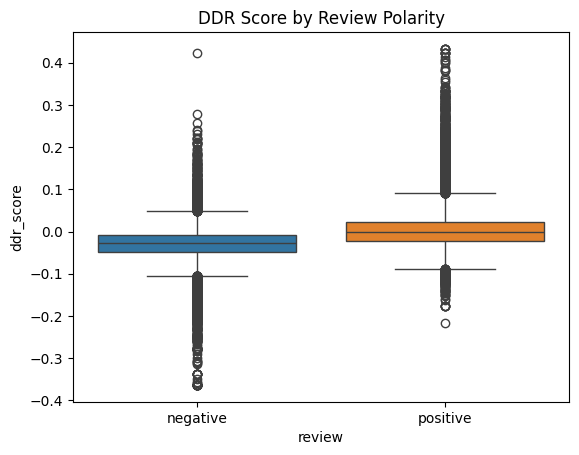

In [218]:
sns.boxplot(data=review_data, x="review", y="ddr_score", hue="review")
plt.title("DDR Score by Review Polarity")
plt.show()

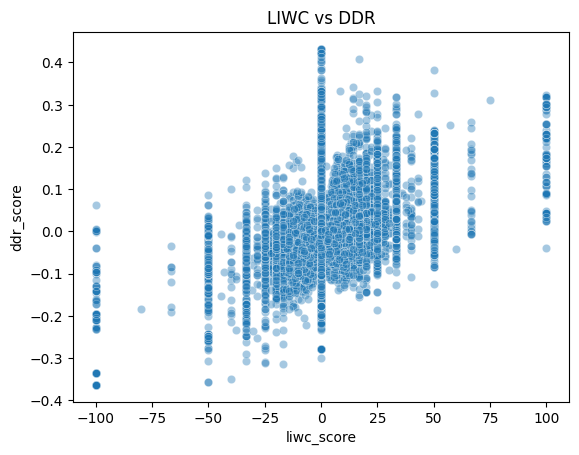

In [219]:
sns.scatterplot(data=review_data, x="liwc_score", y="ddr_score", alpha=0.4)
plt.title("LIWC vs DDR")
plt.show()

In [220]:
review_data[[
    "liwc_score",
    "ddr_score",
]].corr(method="spearman")

,liwc_score,ddr_score
liwc_score,1.000000,0.358138
ddr_score,0.358138,1.000000


In [222]:
review_data.sort_values("ddr_score", ascending=False)[
    ["review_text_processed", "ddr_score"]
].tail(10)

,review_text_processed,ddr_score
14467,fraco,-0.363166
17163,fraco,-0.363166
2597,fraco,-0.363166
1599,fraco,-0.363166
14873,fraco,-0.363166
20238,fraco,-0.363166
19104,fraco,-0.363166
7633,fraco,-0.363166
5515,fraco,-0.363166
6044,fraco,-0.363166


In [223]:
model_ddr = smf.ols(
    "ddr_score ~ review",
    data=review_data
).fit()

print(model_ddr.summary())

                            OLS Regression Results                            
Dep. Variable:              ddr_score   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     7463.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:53:38   Log-Likelihood:                 79388.
No. Observations:               50000   AIC:                        -1.588e+05
Df Residuals:                   49998   BIC:                        -1.588e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0306      0

What about a classifier?

In [224]:
texts = review_data["review_text_processed"]  
labels = review_data["review"]                

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [225]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

pred = clf.predict(X_test_vec)
accuracy_score(y_test, pred)

0.8158

In [227]:
feature_names = vectorizer.get_feature_names_out()
coefficients = clf.coef_[0]

top_words = sorted(
    zip(coefficients, feature_names),
    reverse=True
)

top_words[:10]

[(2.9301372847271923, 'filmaco'),
 (2.752170601237122, 'canso'),
 (2.520815732863102, 'encantador'),
 (2.5202136409014066, 'maravilhoso'),
 (2.436159122287331, 'perfeicao'),
 (2.253591472178323, 'sensacional'),
 (2.183070520284045, 'apaixonante'),
 (2.1405868158085326, 'fantastico'),
 (2.1391465324388004, 'perfeito'),
 (2.106915165531271, 'lindo')]

In [228]:
# use only the test set rows for a fair comparison
y_true = (y_test == "positive").astype(int)

liwc_score = review_data.loc[y_test.index, "liwc_score"]
ddr_score  = review_data.loc[y_test.index, "ddr_score"]

clf_probs = clf.predict_proba(X_test_vec)[:, 1]

roc_auc_liwc = roc_auc_score(y_true, liwc_score)
roc_auc_ddr  = roc_auc_score(y_true, ddr_score)
roc_auc_clf  = roc_auc_score(y_true, clf_probs)

print(f"ROC-AUC  LIWC: {roc_auc_liwc:.3f}")
print(f"ROC-AUC  DDR:  {roc_auc_ddr:.3f}")
print(f"ROC-AUC  CLF:  {roc_auc_clf:.3f}")

ROC-AUC  LIWC: 0.650
ROC-AUC  DDR:  0.729
ROC-AUC  CLF:  0.893


In [206]:
ap_liwc = average_precision_score(y_true, liwc_score)
ap_ddr  = average_precision_score(y_true, ddr_score)
ap_clf  = average_precision_score(y_true, clf_probs)

print(f"PR-AUC  LIWC: {ap_liwc:.3f}")
print(f"PR-AUC  DDR:  {ap_ddr:.3f}")
print(f"PR-AUC  CLF:  {ap_clf:.3f}")

PR-AUC  LIWC: 0.885
PR-AUC  DDR:  0.897
PR-AUC  CLF:  0.984


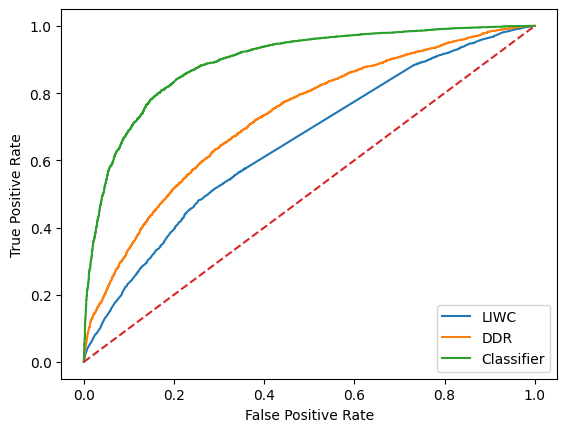

In [229]:
fpr_liwc, tpr_liwc, _ = roc_curve(y_true, liwc_score)
fpr_ddr, tpr_ddr, _ = roc_curve(y_true, ddr_score)
fpr_clf, tpr_clf, _ = roc_curve(y_true, clf_probs)

plt.plot(fpr_liwc, tpr_liwc, label="LIWC")
plt.plot(fpr_ddr, tpr_ddr, label="DDR")
plt.plot(fpr_clf, tpr_clf, label="Classifier")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [208]:
review_data[[
    "review_length",
    "liwc_score",
    "ddr_score",
]].corr(method="spearman")

,review_length,liwc_score,ddr_score
review_length,1.000000,-0.355612,-0.435117
liwc_score,-0.355612,1.000000,0.525828
ddr_score,-0.435117,0.525828,1.000000


Can we improve our "communism" construct detection?

In [230]:
comm_seeds = ['comunista', 'comunismo', 'socialismo', 'marxista', 'socialista', 'marxismo', 'ideologia', 'revolução', 'burguesia', 'esquerda']
whatsapp_data = pd.read_csv("../session_4_dba/data/fakeWhatsApp.BR_2018_content_only.csv")

In [231]:
comm_vec = average_vector(comm_seeds)

comm_vecs = np.vstack([
    document_vector(text) 
    for text in whatsapp_data["text"]
])

comm_sims = cosine_similarity(comm_vecs, comm_vec.reshape(1, -1))

whatsapp_data["ddr_comm"] = comm_sims[:, 0]

In [232]:
whatsapp_data.sort_values(by="ddr_comm", ascending=False)["text"].to_list()[:10] # note 6th example

['Telegram\n\nRamon:\n🔴 CANAIS com informações selecionadas❗️🇧🇷🇧🇷🇧🇷🇧🇷\n🇧🇷Compartilhe❗️\n@BRASIL_LIBERAL\n@OlavoTemRazaoCanal\n@JairMessiasBolsonaro\n@livrosdedireita\n@leandroru\n@criticanacional\n@reaconaria\n@tercalivre\n@conexaopoliticabr\n@desesquerdizada\n@denunciasdireita\n@eusoumbc\n@israeldefato\n@podcastdepre\n@cmt_brasil\n@MouraodoBrasil\n@sigajairbolsonaro\n@altacultura\n@filosofando\n@Soldados\n@PatriotasConservadores\n@enDireitaBR2018\n@PatriAmada\n@missaocefas\n@oantagonista\n@aconteceu\n@CorrupcaoBR\n@gazeta_do_povo\n@estadao\n@mamaefalei\n🇧🇷Vivemos uma guerra cultural\n🇧🇷 Só através da transformação cultural é que garantiremos nossa liberdade🇧🇷\n🇧🇷Compartilhe❗️',
 'Atenção, a pesquisa abaixo foi feita pela instituição Paraná Pesquisas e já está registrada no TSE, porém, nenhuma emissora de TV ou jornal quis divulgar.\n\nNova pesquisa da Paraná Pesquisas mostra Bolsonaro na frente em todos os estados mesmo com Lula candidato. *A Globo não quer divulgar.*\n\n*Pesquisa est

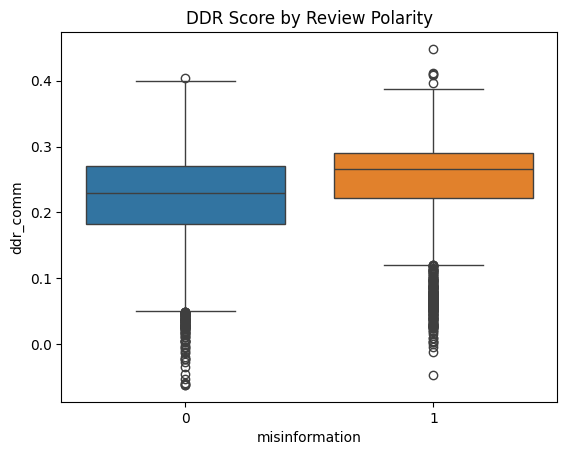

In [233]:
sns.boxplot(data=whatsapp_data, x="misinformation", y="ddr_comm", hue="misinformation", legend=False)
plt.title("DDR Score by Review Polarity")
plt.show()

In [234]:
model_ddr_comm = smf.ols(
    "ddr_comm ~ misinformation",
    data=whatsapp_data
).fit()

print(model_ddr_comm.summary())

                            OLS Regression Results                            
Dep. Variable:               ddr_comm   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     288.7
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.86e-63
Time:                        16:00:45   Log-Likelihood:                 8532.9
No. Observations:                6926   AIC:                        -1.706e+04
Df Residuals:                    6924   BIC:                        -1.705e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.2188      0.001    186.

In [235]:
def color_text(text, ref_vec, window=4):

    tokens = re.findall(r"\b\w+\b", text.lower())

    # word embeddings
    vecs = np.vstack([ft.get_word_vector(w) for w in tokens])

    # rolling mean (vectorized)
    roll = np.array([
        vecs[max(0,i-window//2):i+window//2+1].mean(axis=0)
        for i in range(len(vecs))
    ])

    # cosine similarity
    sims = cosine_similarity(roll, ref_vec.reshape(1,-1)).flatten()

    # color scale
    ansi_scale = [63,105,147,189,188,230,223,224,217,210,203,196,160,124]

    idx = np.interp(
        sims,
        (np.nanmin(sims), np.nanmax(sims)),
        (0, len(ansi_scale)-1)
    ).round().astype(int)

    # print
    for w, c in zip(tokens, np.array(ansi_scale)[idx]):
        print(f"\033[48;5;{c}m{w}\033[0m", end=" ")

    print()

In [241]:
# highest
top_text = whatsapp_data.loc[
    whatsapp_data["ddr_comm"].idxmax(), 
    "text"
]

# lowest
bottom_text = whatsapp_data.loc[
    whatsapp_data["ddr_comm"].idxmin(), 
    "text"
]

print(bottom_text)
color_text(bottom_text, comm_vec)

LIMPEZA ATUALIZADA: 
Suplicy ✖
Lindenbergh ✖
Dilma ✖
Pimentel ✖
Rosseto ✖
Requiao ✖
Cristovam Buarque ✖
Beto Richa ✖
Jean Wyllis ✖
Vanessa Graziottin ✖
Edison lobao ✖
Vicentinho ✖
Sarney filho ✖
Jorge Viana ✖
Roseana Sarney ✖
limpeza atualizada suplicy lindenbergh dilma pimentel rosseto requiao cristovam buarque beto richa jean wyllis vanessa graziottin edison lobao vicentinho sarney filho jorge viana roseana sarney 


Let's work with uncategorized data

In [242]:
#brpolicorpus_CPI = pd.read_csv("data/BrPoliCorpus_CPI.csv")
brpolicorpus = pd.read_parquet("data/BrPoliCorpus_Floor.parquet")
brpolicorpus.head(10)

,Sessao,Quarto,Orador,HorarioQuarto,FaseSessaoSG,Data,FaseSessao,TipoSessaoTXT,HoraQuarto,Discurso,Apelido,Estado,Partido,Bloco
0,003.3.51.E,39.0,2.0,15:16:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:16:00,"- Sr. Presidente, Srs. Deputados, o Brasil int...",LUIZ SÉRGIO,RJ,PT,False
1,003.3.51.E,38.0,2.0,15:14:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:14:00,"- Sr. Presidente, Sras. e Srs. Deputados, todo...",PEDRO FERNANDES,MA,PFL,False
2,003.3.51.E,36.0,2.0,15:10:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:10:00,"- Sr. Presidente, esses dias vimos assistindo ...",FERNANDO FERRO,PE,PT,False
3,003.3.51.E,34.0,1.0,15:06:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:06:00,"- Sr. Presidente, Sras. e Srs. Deputados, mais...",REGIS CAVALCANTE,AL,PPS,False
4,003.3.51.E,33.0,2.0,15:04:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:04:00,"- Sr. Presidente, Sras. e Srs. Deputados, o PT...",PAULO GOUVÊA,SC,PFL,False
5,003.3.51.E,33.0,1.0,15:04:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:04:00,"- Sr. Presidente, peço seja registrado nos Ana...",MILTON TEMER,RJ,PT,False
6,003.3.51.E,32.0,2.0,15:02:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,15:02:00,"- Sr. Presidente, Sras. e Srs. Deputados, a hu...",SIMÃO SESSIM,RJ,PPB,False
7,003.3.51.E,29.0,1.0,14:56:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,14:56:00,"- Sr. Presidente, quero fazer um registro a re...",EDISON ANDRINO,SC,PMDB,True
8,003.3.51.E,29.0,2.0,14:56:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,14:56:00,"- Sr. Presidente, Sras. e Srs. Deputados, gost...",DR. HÉLIO,SP,PDT,False
9,003.3.51.E,28.0,2.0,14:54:00,PE,28/12/2000,Pequeno Expediente,Ordinária - CD,14:54:00,"- Sr. Presidente, Sras. e Srs. Deputados, a PE...",FRANCISCO RODRIGUES,RR,PFL,False


In [ ]:
filtered_CPI = brpolicorpus_CPI[
    (brpolicorpus_CPI["para_depor"] | brpolicorpus_CPI["para_expor"]) &
    (brpolicorpus_CPI["texto"].str.split().str.len() >= 10)
]

len(filtered_CPI)

In [ ]:
sample = brpolicorpus.sample(n=1000, random_state=42)

In [ ]:
fact_speaking = ['realidade', 'avaliar', 'examinar', 'evidência', 'fato', 'verdade', 'prova']
belief_speaking = ['acreditar', 'opinião', 'considerar', 'sentir', 'intuição', 'senso comum']

In [243]:
fact_speaking = [
    "de fato",
    "analisar",
    "avaliar",
    "correto",
    "correção",
    "determinar",
    "avaliar",
    "evidência",
    "examinar",
    "exploração",
    "fato",
    "informação",
    "inspecionar",
    "investigar",
    "observar",
    "prova",
    "provar",
    "questão",
    "questionário",
    "real",
    "realidade",
    "retificar",
    "pesquisa",
    "revisar",
    "amostra",
    "ciência",
    "escrutinar",
    "buscar",
    "especificar",
    "supervisionar",
    "testar",
    "rastrear",
    "monitorar",
    "teste",
    "verdade",
    "validar",
    "verificar"
]

belief_speaking = [
    "basicamente",
    "acreditar",
    "afirmar",
    "confiar",
    "considerar",
    "contemplar",
    "contenda",
    "vislumbrar",
    "sentir",
    "francamente",
    "genuinamente",
    "achar",
    "insinuar",
    "julgar",
    "parecer",
    "óbvio",
    "obviamente",
    "claro",
    "opinião",
    "claramente",
    "ponderar",
    "posição",
    "presumir",
    "provavelmente",
    "parecer",
    "sensação",
    "sentimento",
    "sinal",
    "sugerir",
    "sugestão",
    "supor",
    "certamente",
    "pensar",
    "confiar",
    "tentar",
    "visão",
    "praticamente"
]

belief_vec = average_vector(belief_speaking)
fact_vec = average_vector(fact_speaking)

CPI

In [ ]:
brpoli_CPI_doc_vecs = np.vstack([
    document_vector(text) 
    for text in filtered_CPI["texto"]
])

In [ ]:
sims_CPI = cosine_similarity(brpoli_CPI_doc_vecs, [fact_vec, belief_vec])
standardized_CPI = StandardScaler().fit_transform(sims_CPI)

filtered_CPI["ddr_fact"] = sims_CPI[:, 0]
filtered_CPI["ddr_belief"] = sims_CPI[:, 1]
filtered_CPI["ddr_score"] = standardized_CPI[:, 0] - standardized_CPI[:, 1]

In [ ]:
filtered_CPI.sort_values(by = "ddr_score", ascending=False)["partido_sigla"]

Floor

In [244]:
# brpoli_doc_vecs = np.vstack([
#     document_vector(text) 
#     for text in brpolicorpus["Discurso"]
# ])

brpoli_doc_vecs = np.load("data/brpoli_doc_vecs.npy")

In [246]:
sims_floor = cosine_similarity(brpoli_doc_vecs, [fact_vec, belief_vec])
standardized_floor = StandardScaler().fit_transform(sims_floor)

brpolicorpus["ddr_fact"] = sims_floor[:, 0]
brpolicorpus["ddr_belief"] = sims_floor[:, 1]
brpolicorpus["ddr_score"] = standardized_floor[:, 0] - standardized_floor[:, 1]

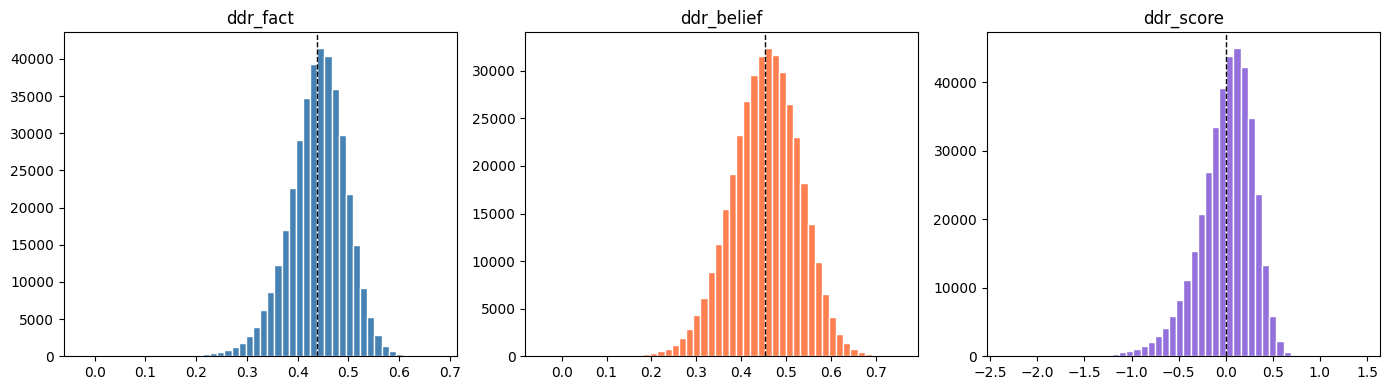

In [247]:
# 1. Basic distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes, 
                           ["ddr_fact", "ddr_belief", "ddr_score"],
                           ["steelblue", "coral", "mediumpurple"]):
    ax.hist(brpolicorpus[col], bins=50, color=color, edgecolor="white")
    ax.set_title(col)
    ax.axvline(brpolicorpus[col].mean(), color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
# brpolicorpus["text_length"] = brpolicorpus["Discurso"].str.split().str.len()

# for col in ["ddr_fact", "ddr_belief", "ddr_score"]:
#     r, p = stats.pearsonr(brpolicorpus["text_length"], brpolicorpus[col])
#     print(f"Length vs {col}: r={r:.3f}, p={p:.3f}")

Length vs ddr_fact: r=0.020, p=0.000
Length vs ddr_belief: r=-0.052, p=0.000
Length vs ddr_score: r=0.247, p=0.000


C:\Users\fabio\AppData\Local\Temp\ipykernel_9472\3813108399.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(brpolicorpus["ddr_fact"], brpolicorpus["ddr_belief"],


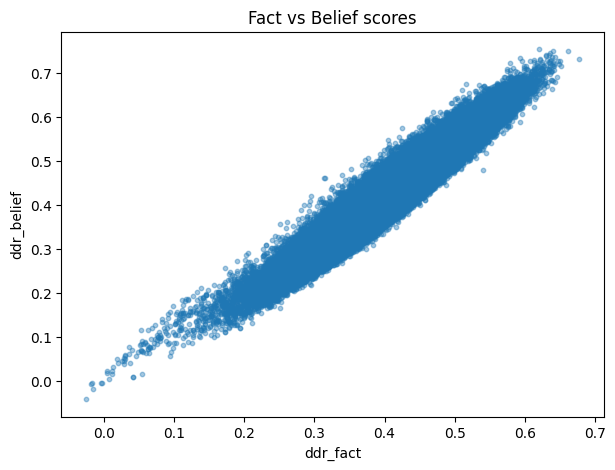

In [250]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(brpolicorpus["ddr_fact"], brpolicorpus["ddr_belief"], 
                 cmap="viridis", alpha=0.4, s=10)
plt.xlabel("ddr_fact")
plt.ylabel("ddr_belief")
plt.title("Fact vs Belief scores")
plt.show()

In [251]:
r, p = stats.pearsonr(brpolicorpus["ddr_fact"], brpolicorpus["ddr_belief"])
print(f"Correlation fact vs belief: r={r:.3f}, p={p:.3f}")

Correlation fact vs belief: r=0.957, p=0.000


In [252]:
import re

# canonical party list
valid_parties = {
    'PT', 'PSDB', 'PMDB', 'MDB', 'PFL', 'DEM', 'PP', 'PPB', 'PDT',
    'PSB', 'PPS', 'PTB', 'PL', 'PCdoB', 'PCDOB', 'PSL', 'PV', 'PSOL',
    'PRB', 'PR', 'SD', 'PROS', 'PSD', 'SOLIDARIEDADE', 'PODE', 'PODEMOS',
    'REPUBLICANOS', 'NOVO', 'CIDADANIA', 'PATRIOTA', 'AVANTE', 'REDE',
    'PSC', 'PTC', 'PTdoB', 'PCdoB', 'PMN', 'PHS', 'PST', 'PRONA',
    'PRTB', 'PPL', 'PAN', 'PRB', 'PMB', 'PEN', 'SDD', 'UNIÃO'
}

def clean_party(value):
    if pd.isna(value):
        return None
    # try to find a known party acronym in the string
    value_upper = value.upper().strip()
    # direct match first
    if value_upper in {p.upper() for p in valid_parties}:
        return value_upper
    # look for known party after a dot or slash or at end of string
    match = re.search(r'[\.\s/]([A-Z]{2,15})[\s\.\)]?$', value.strip())
    if match:
        candidate = match.group(1).upper()
        if candidate in {p.upper() for p in valid_parties}:
            return candidate
    # scan for any known party anywhere in string
    for party in sorted(valid_parties, key=len, reverse=True):
        if re.search(r'\b' + re.escape(party.upper()) + r'\b', value_upper):
            return party.upper()
    return None

brpolicorpus["partido_clean"] = brpolicorpus["Partido"].apply(clean_party)

# check coverage
print(brpolicorpus["partido_clean"].isna().sum(), "unmatched")
print(brpolicorpus["partido_clean"].value_counts().head(20))

1798 unmatched
partido_clean
PT       86520
PMDB     37255
PSDB     32962
PSB      21265
PP       18221
PCDOB    17263
PDT      17084
DEM      16103
PSOL     15468
PTB      14842
PFL      12734
PPS      11873
PL       11731
PSD      10626
PR       10206
PSC       5919
PV        5595
PSL       4651
NOVO      4334
PRB       4006
Name: count, dtype: int64


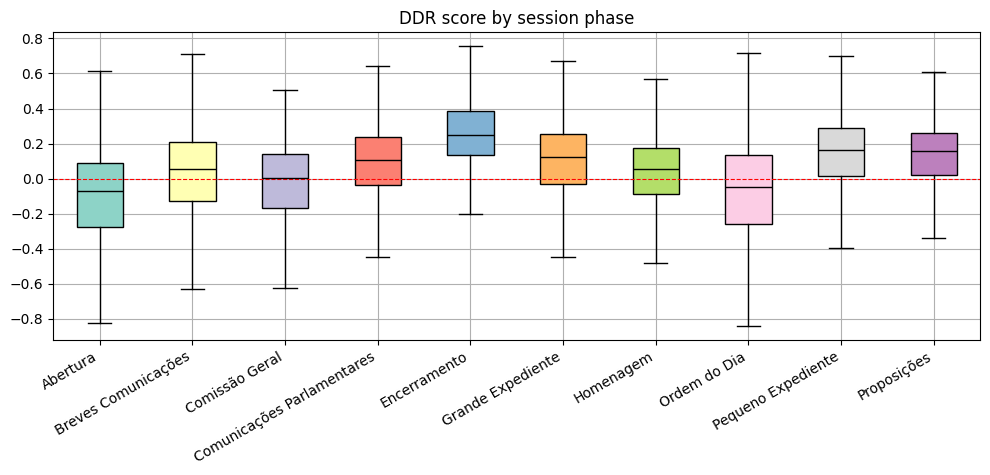

In [262]:
fig, ax = plt.subplots(figsize=(10, 5))

fase_order = (brpolicorpus.groupby("FaseSessao")["ddr_score"]
              .mean()
              .sort_values()
              .index.tolist())

bp = brpolicorpus.dropna(subset=["FaseSessao"]).boxplot(
    column="ddr_score", by="FaseSessao", ax=ax, showfliers=False, patch_artist=True,
    return_type="dict", color="black"
)

colors = plt.cm.Set3.colors[:len(fase_order)]
for patch, color in zip(bp["ddr_score"]["boxes"], colors):
    patch.set_facecolor(color)

ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_title("DDR score by session phase")
ax.set_xlabel("")
plt.suptitle("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

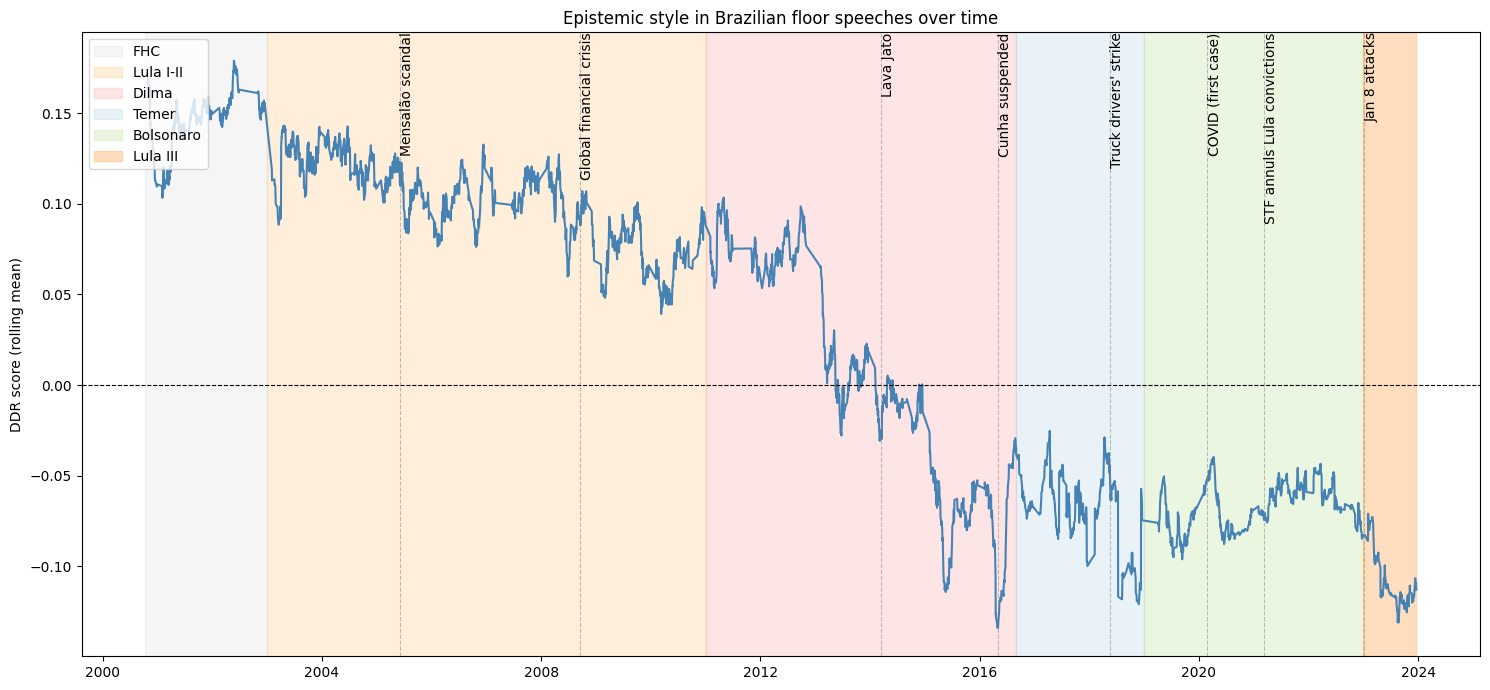

In [259]:
brpolicorpus["Data"] = pd.to_datetime(brpolicorpus["Data"], dayfirst=True)
brpolicorpus["era"] = pd.cut(
    brpolicorpus["Data"],
    bins=pd.to_datetime([
        "1995-01-01", 
        "2003-01-01", 
        "2011-01-01", 
        "2016-09-01", 
        "2019-01-01", 
        "2023-01-01",
        "2026-01-01" 
    ]),
    labels=[
        "FHC",
        "Lula I-II",
        "Dilma",
        "Temer",
        "Bolsonaro",
        "Lula III"
    ]
)

daily = (brpolicorpus
         .groupby("Data")["ddr_score"]
         .mean()
         .reset_index()
         .sort_values("Data"))

daily["ddr_rolling"] = daily["ddr_score"].rolling(window=30, min_periods=10).mean()

era_bounds = {
    "FHC":        ("1995-01-01", "2003-01-01", "#d9d9d9"),
    "Lula I-II":  ("2003-01-01", "2011-01-01", "#fdbf6f"),
    "Dilma":      ("2011-01-01", "2016-09-01", "#fb9a99"),
    "Temer":      ("2016-09-01", "2019-01-01", "#a6cee3"),
    "Bolsonaro":  ("2019-01-01", "2023-01-01", "#b2df8a"),
    "Lula III":   ("2023-01-01", None, "#ff7f00"),
}

events = {
    "Lava Jato": "2014-03-17",
    "Truck drivers' strike": "2018-05-21",
    "COVID (first case)": "2020-02-26",
    "STF annuls Lula convictions": "2021-03-08",
    "Jan 8 attacks": "2023-01-08",
    "Global financial crisis": "2008-09-15",
    "Mensalão scandal": "2005-06-06",
    "Cunha suspended": "2016-05-05",
}


# line plot
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(daily["Data"], daily["ddr_rolling"], color="steelblue", linewidth=1.5)

for label, date in events.items():
    ax.axvline(
        pd.Timestamp(date),
        color="grey",
        linestyle="--",
        alpha=0.5,
        linewidth=0.8
    )
    ax.text(
        pd.Timestamp(date),
        ax.get_ylim()[1],
        label,
        rotation=90,
        va="top",
        fontsize=10,
        color="black"
    )

data_start = daily["Data"].min()
data_end = daily["Data"].max()

seen = set()
for era, (start, end, color) in era_bounds.items():
    start = max(pd.Timestamp(start), data_start)
    end = pd.Timestamp(end) if end else data_end
    end = min(end, data_end)

    label = era if era not in seen else None
    ax.axvspan(start, end, alpha=0.25, color=color, label=label)
    seen.add(era)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("DDR score (rolling mean)")
ax.set_title("Epistemic style in Brazilian floor speeches over time")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

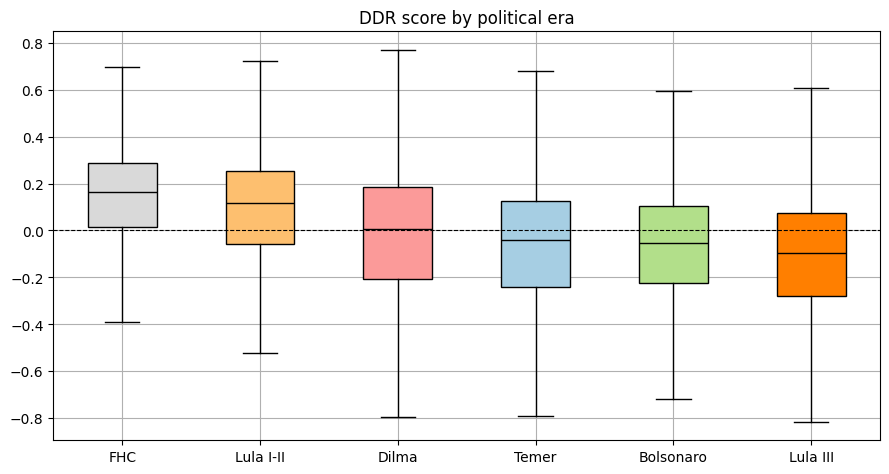

In [260]:
fig, ax = plt.subplots(figsize=(9, 5))

era_order = ["FHC", "Lula I-II", "Dilma", "Temer", "Bolsonaro", "Lula III"]

era_colors = {
    "FHC": "#d9d9d9",
    "Lula I-II": "#fdbf6f",
    "Dilma": "#fb9a99",
    "Temer": "#a6cee3",
    "Bolsonaro": "#b2df8a",
    "Lula III": "#ff7f00"
}

bp = brpolicorpus.dropna(subset=["era"]).boxplot(
    column="ddr_score",
    by="era",
    ax=ax,
    showfliers=False,
    patch_artist=True,
    return_type="dict",
    color="black"
)

for patch, era in zip(bp["ddr_score"]["boxes"], era_order):
    patch.set_facecolor(era_colors[era])

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("DDR score by political era")
ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

C:\Users\fabio\AppData\Local\Temp\ipykernel_9472\3019289986.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["era", "bloc"])["ddr_score"]


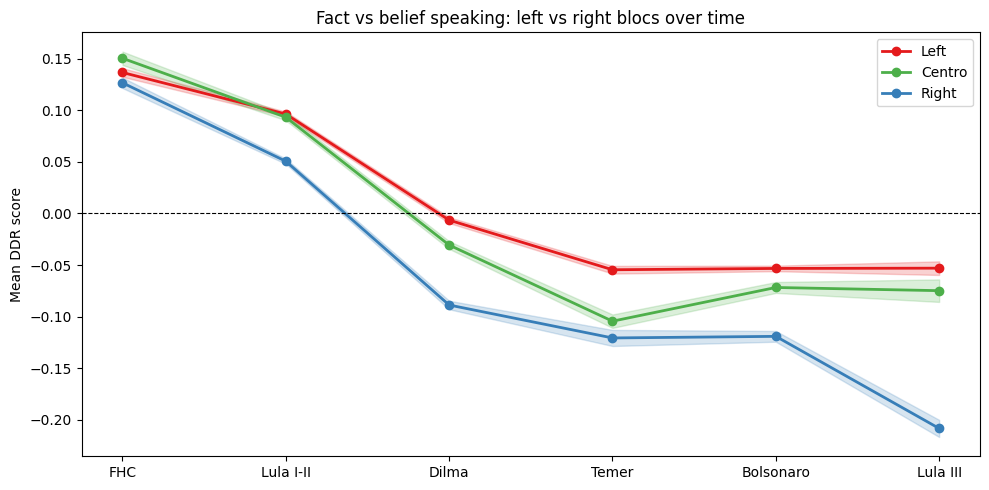

In [261]:
left   = ["PT", "PSB", "PDT", "PSOL", "PCDOB"]
right  = ["PSDB", "DEM", "PFL", "PP", "PSL", "PL"]
centro = ["PMDB", "MDB", "PSD", "PTB", "PR", "PROS", "SD", "REPUBLICANOS", "PODE", "PODEMOS", "CIDADANIA"]

party_era = (brpolicorpus
             .dropna(subset=["era", "partido_clean"])
             .assign(bloc=lambda d: d["partido_clean"].map(
                 {p: "Left"   for p in left}   |
                 {p: "Right"  for p in right}  |
                 {p: "Centro" for p in centro}
             ))
             .dropna(subset=["bloc"])
             .groupby(["era", "bloc"])["ddr_score"]
             .agg(["mean", "sem"])
             .reset_index())

party_era["ci"] = party_era["sem"] * 1.96

era_order = ["FHC", "Lula I-II", "Dilma", "Temer", "Bolsonaro", "Lula III"]

fig, ax = plt.subplots(figsize=(10, 5))

for bloc, color in [("Left", "#e41a1c"), ("Centro", "#4daf4a"), ("Right", "#377eb8")]:
    d = (party_era
         .query("bloc == @bloc")
         .set_index("era")
         .reindex(era_order)
         .reset_index())
    
    ax.plot(d["era"], d["mean"], marker="o", label=bloc, color=color, linewidth=2)
    ax.fill_between(
        d["era"],
        d["mean"] - d["ci"],
        d["mean"] + d["ci"],
        alpha=0.2,
        color=color
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Mean DDR score")
ax.set_title("Fact vs belief speaking: left vs right blocs over time")
ax.legend()

plt.tight_layout()
plt.show()

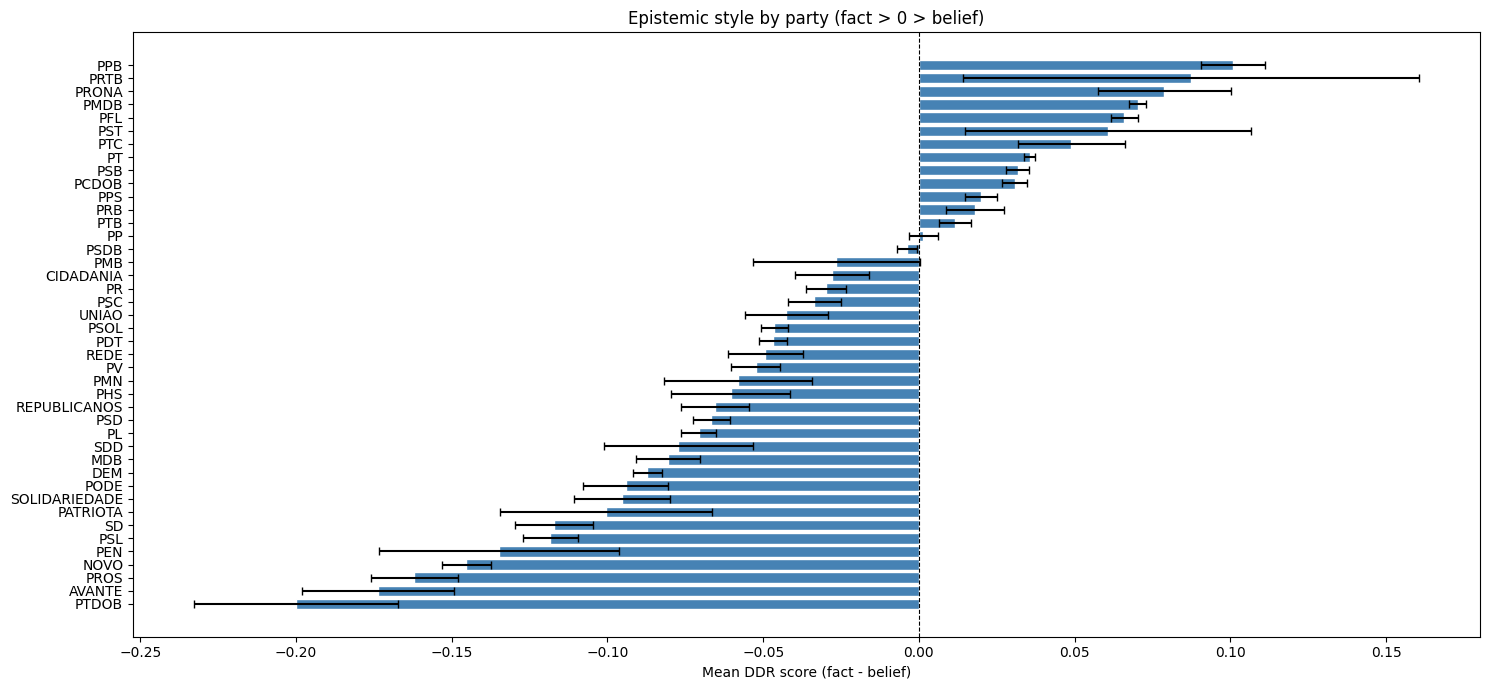

In [255]:
party_counts = brpolicorpus["partido_clean"].value_counts()
valid_parties = party_counts[party_counts >= 30].index
party_data = brpolicorpus[brpolicorpus["partido_clean"].isin(valid_parties)]

party_means = (party_data.groupby("partido_clean")["ddr_score"]
               .agg(["mean", "sem", "count"])
               .sort_values("mean"))

fig, ax = plt.subplots(figsize=(15, 7))
ax.barh(party_means.index, party_means["mean"],
        xerr=1.96 * party_means["sem"],
        color="steelblue", edgecolor="white", capsize=3)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean DDR score (fact - belief)")
ax.set_title("Epistemic style by party (fact > 0 > belief)")
plt.tight_layout()
plt.show()

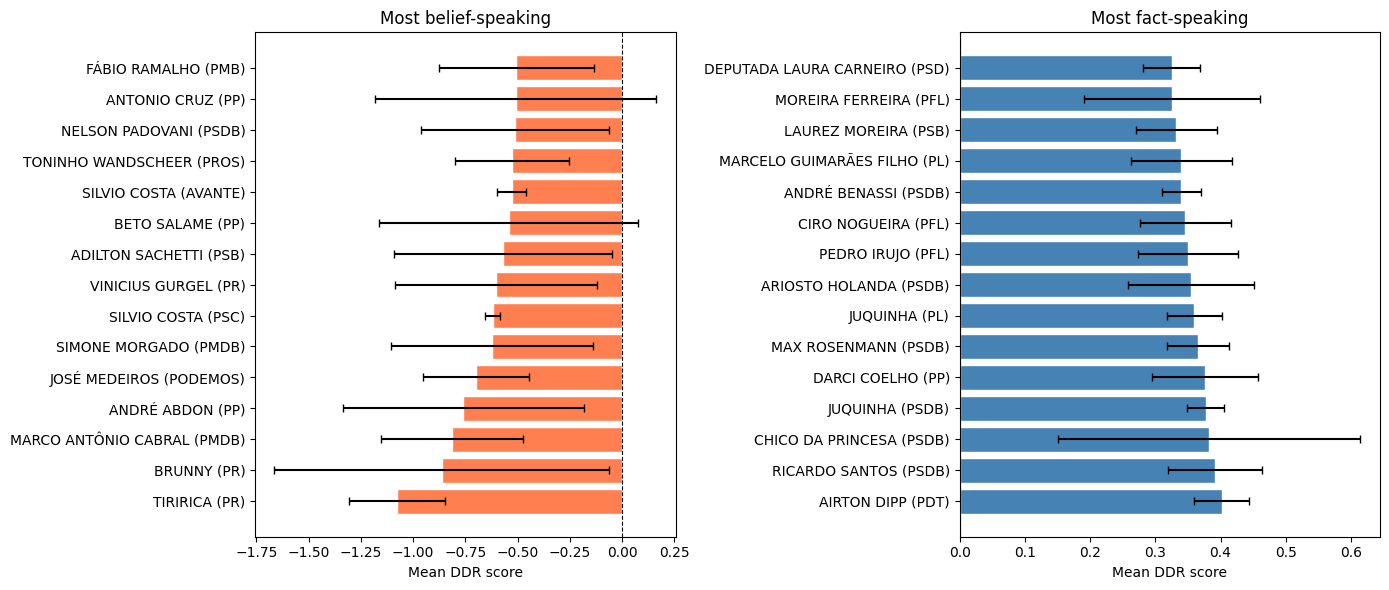

In [263]:
speaker_stats = (brpolicorpus.groupby(["Apelido", "partido_clean"])["ddr_score"]
                 .agg(["mean", "sem", "count"])
                 .reset_index()
                 .query("count >= 5")
                 .sort_values("mean"))

speaker_stats["ci"] = speaker_stats["sem"] * 1.96

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in zip(
    axes,
    [speaker_stats.head(15), speaker_stats.tail(15).iloc[::-1]],
    ["Most belief-speaking", "Most fact-speaking"]
):
    labels = data["Apelido"] + " (" + data["partido_clean"].fillna("?") + ")"
    ax.barh(labels, data["mean"], xerr=data["ci"],
            color="steelblue" if "fact" in title else "coral",
            capsize=3, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Mean DDR score")

plt.tight_layout()
plt.show()

In [264]:
speaker_era = (
    brpolicorpus
    .query("era in ['Lula I-II', 'Lula III']")
    .groupby("Apelido")
    .filter(lambda x: 
        (x["era"].value_counts().get("Lula I-II", 0) >= 5) &
        (x["era"].value_counts().get("Lula III", 0) >= 5)
    )
    .groupby(["Apelido", "era"])["ddr_score"]
    .mean()
    .unstack()
)

speaker_era["change"] = speaker_era["Lula III"] - speaker_era["Lula I-II"]

C:\Users\fabio\AppData\Local\Temp\ipykernel_9472\3762609559.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Apelido", "era"])["ddr_score"]


In [265]:
speaker_era.sort_values("change")["change"].values

array([-0.44503558, -0.43866944, -0.31119427, -0.2867037 , -0.2864778 ,
       -0.26216823, -0.25652018, -0.24965745, -0.24570125, -0.23538631,
       -0.23398124, -0.22918308, -0.22002491, -0.21472535, -0.20777933,
       -0.20468423, -0.19417268, -0.18043867, -0.17894569, -0.17421402,
       -0.17329589, -0.17210384, -0.16709688, -0.16430108, -0.16244094,
       -0.1599217 , -0.15648186, -0.14880225, -0.14787245, -0.12224752,
       -0.1221097 , -0.10930078, -0.10915226, -0.09482334, -0.08840144,
       -0.08653535, -0.05011545, -0.04720724, -0.04514783, -0.00452128,
        0.00053681,  0.00682836,  0.05577326,  0.08024263,  0.1824333 ],
      dtype=float32)

In [266]:
top_neg = speaker_era["change"].nsmallest(12).index

plot_data = brpolicorpus[
    brpolicorpus["Apelido"].isin(top_neg) &
    brpolicorpus["era"].isin(["Lula I-II","Lula III"])
]

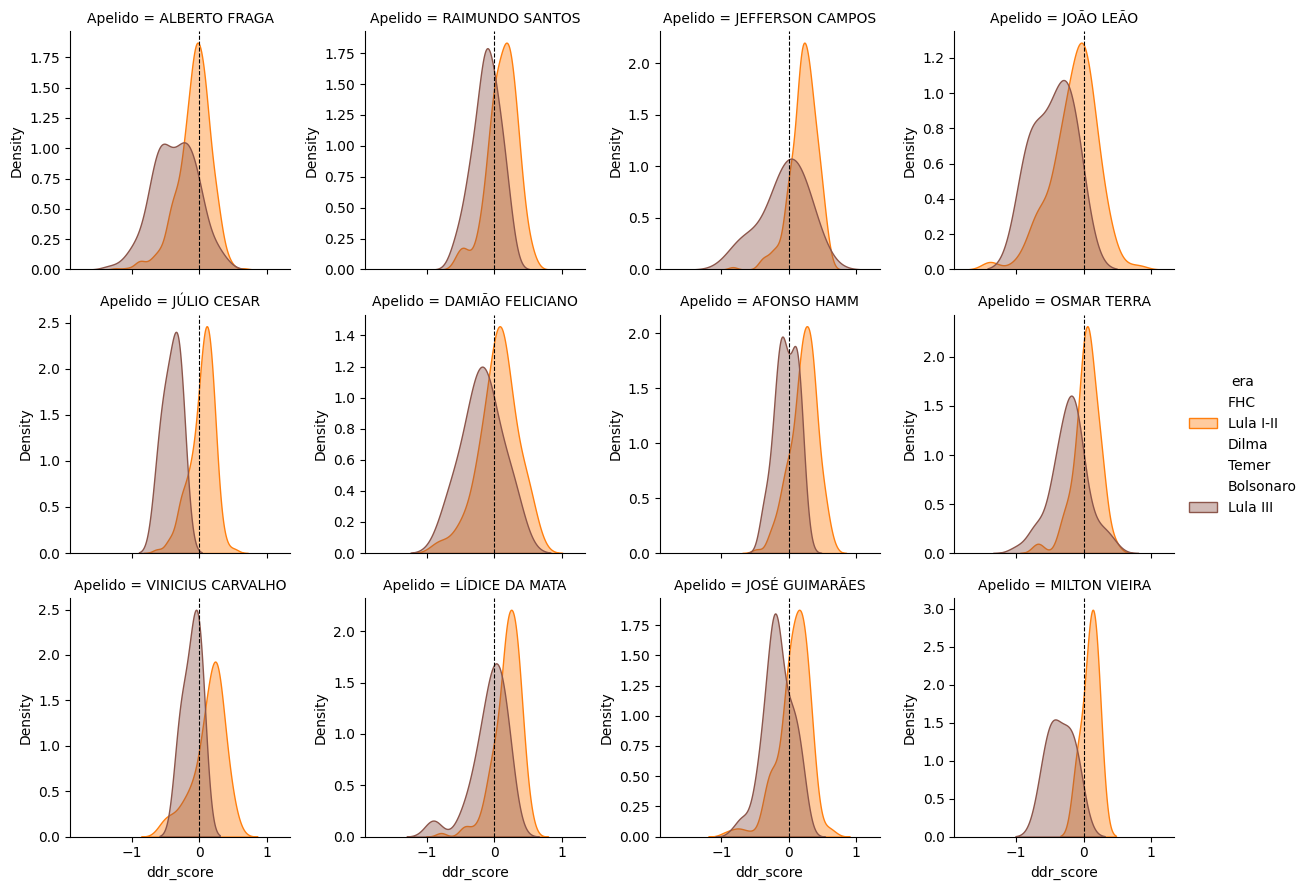

In [267]:
g = sns.FacetGrid(
    plot_data,
    col="Apelido",
    col_wrap=4,
    hue="era",
    sharex=True,
    sharey=False,
    height=3
)

g.map(sns.kdeplot, "ddr_score", fill=True, alpha=0.4)
g.add_legend()

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", color="black", linewidth=0.8)

plt.show()

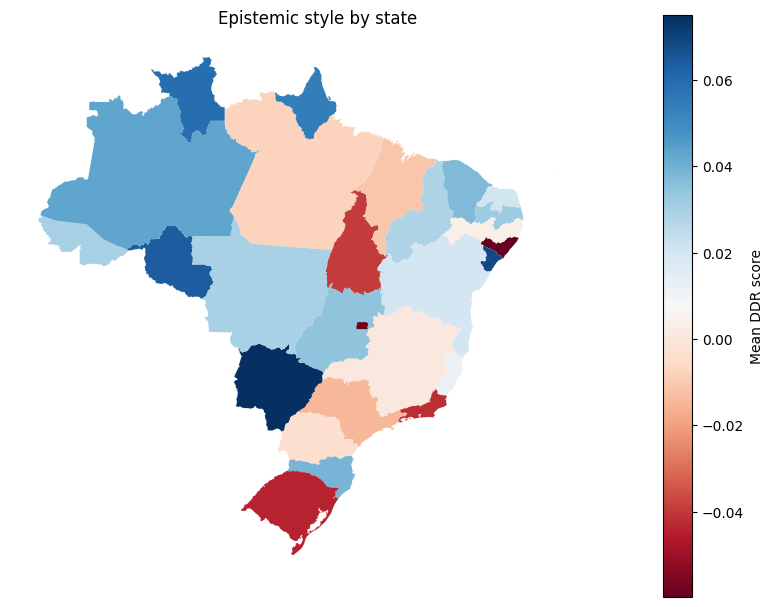

In [268]:
brazil = geobr.read_state(year=2020)

state_means = (brpolicorpus.groupby("Estado")["ddr_score"]
               .mean()
               .reset_index()
               .rename(columns={"Estado": "abbrev_state", "ddr_score": "ddr_mean"}))

brazil = brazil.merge(state_means, on="abbrev_state", how="left")

fig, ax = plt.subplots(figsize=(8, 10))
brazil.plot(column="ddr_mean", cmap="RdBu", legend=True,
            missing_kwds={"color": "lightgrey"},
            legend_kwds={"label": "Mean DDR score", "shrink": 0.6},
            ax=ax)
ax.set_title("Epistemic style by state")
ax.axis("off")
plt.tight_layout()
plt.show()

In [269]:
n_iterations = 200
drop_pct = 0.20

perturbed_scores = []

for i in range(n_iterations):
    n_drop_fact = int(len(fact_speaking) * drop_pct)
    n_drop_belief = int(len(belief_speaking) * drop_pct)
    
    fact_sample = np.random.choice(fact_speaking, 
                                    size=len(fact_speaking) - n_drop_fact, 
                                    replace=False).tolist()
    belief_sample = np.random.choice(belief_speaking, 
                                      size=len(belief_speaking) - n_drop_belief, 
                                      replace=False).tolist()
    
    fact_vec_p = average_vector(fact_sample)
    belief_vec_p = average_vector(belief_sample)
    
    sims_p = cosine_similarity(brpoli_doc_vecs, [fact_vec_p, belief_vec_p])
    std_p = StandardScaler().fit_transform(sims_p)
    scores_p = std_p[:, 0] - std_p[:, 1]
    
    perturbed_scores.append(scores_p)

perturbed_scores = np.array(perturbed_scores) 

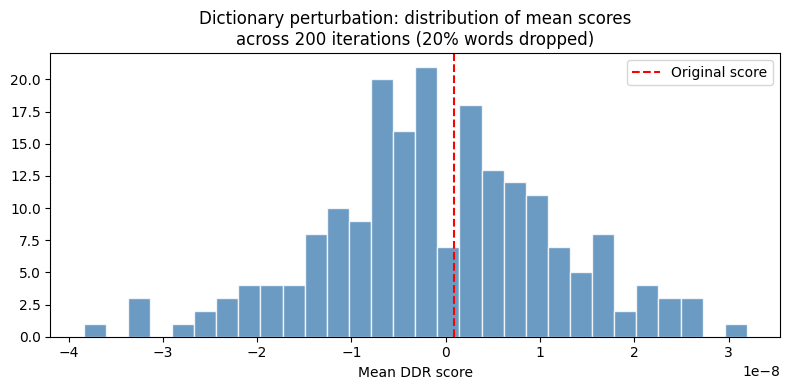

In [270]:
iteration_means = perturbed_scores.mean(axis=1)
original_mean = brpolicorpus["ddr_score"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(iteration_means, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(original_mean, color="red", linestyle="--", linewidth=1.5, label="Original score")
ax.set_xlabel("Mean DDR score")
ax.set_title("Dictionary perturbation: distribution of mean scores\nacross 200 iterations (20% words dropped)")
ax.legend()
plt.tight_layout()
plt.show()

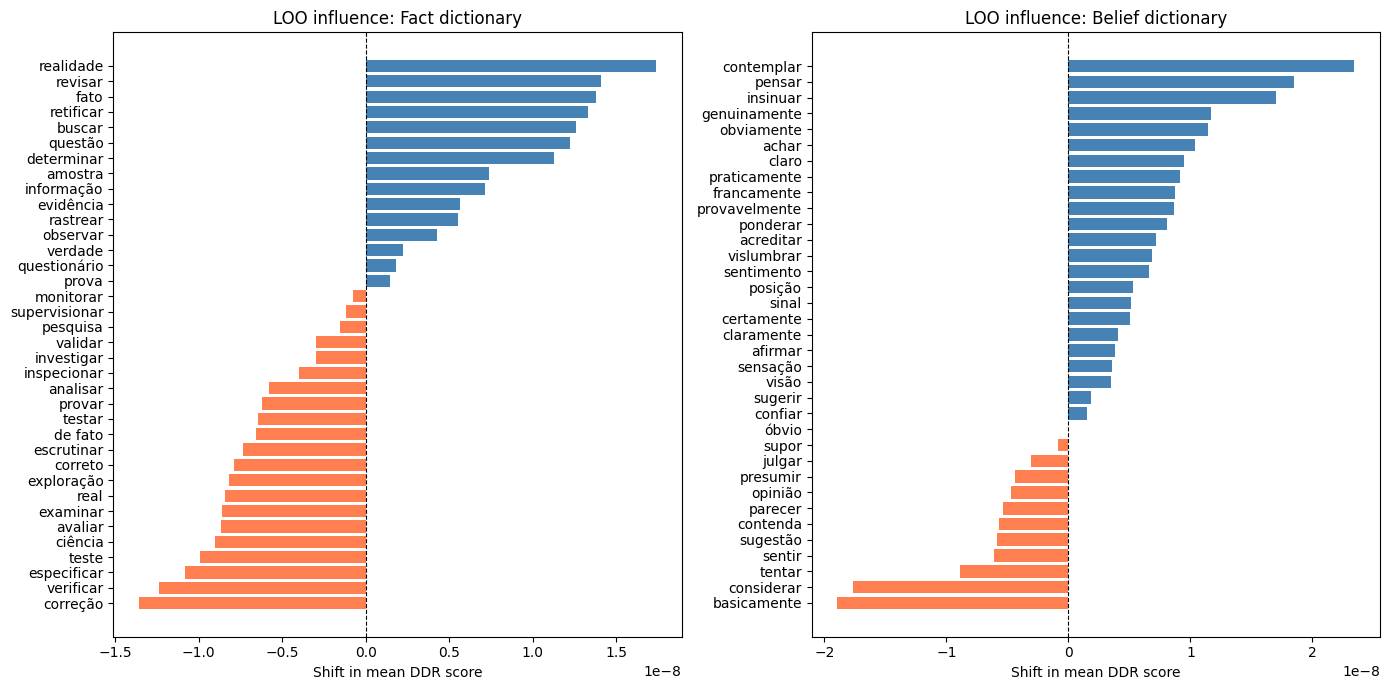

In [272]:
# leave-one-out for fact dictionary
fact_loo = {}
for word in fact_speaking:
    reduced = [w for w in fact_speaking if w != word]
    fact_vec_r = average_vector(reduced)
    sims_r = cosine_similarity(brpoli_doc_vecs, [fact_vec_r, belief_vec])
    std_r = StandardScaler().fit_transform(sims_r)
    fact_loo[word] = (std_r[:, 0] - std_r[:, 1]).mean()

# leave-one-out for belief dictionary
belief_loo = {}
for word in belief_speaking:
    reduced = [w for w in belief_speaking if w != word]
    belief_vec_r = average_vector(reduced)
    sims_r = cosine_similarity(brpoli_doc_vecs, [fact_vec, belief_vec_r])
    std_r = StandardScaler().fit_transform(sims_r)
    belief_loo[word] = (std_r[:, 0] - std_r[:, 1]).mean()

original_mean = brpolicorpus["ddr_score"].mean()

# compute influence as deviation from original
fact_influence = {w: s - original_mean for w, s in fact_loo.items()}
belief_influence = {w: s - original_mean for w, s in belief_loo.items()}

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, influence, title in zip(
    axes,
    [fact_influence, belief_influence],
    ["Fact dictionary", "Belief dictionary"]
):
    words = list(influence.keys())
    values = list(influence.values())
    order = np.argsort(values)
    ax.barh([words[i] for i in order], [values[i] for i in order],
            color=["coral" if v < 0 else "steelblue" for v in [values[i] for i in order]])
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"LOO influence: {title}")
    ax.set_xlabel("Shift in mean DDR score")

plt.tight_layout()
plt.show()